# Окружение

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Загрузка гравитационного датасета...
Размер обучающей выборки: 54388 пикселей
Размер валидационной выборки: 13598回忆 пикселей

Запуск обучения CatBoost на гравитационных полях потенциала...
0:	learn: 0.0000722	test: 0.0000686	best: 0.0000686 (0)	total: 160ms	remaining: 3m 12s
100:	learn: 0.0000451	test: 0.0000437	best: 0.0000437 (100)	total: 551ms	remaining: 5.99s
200:	learn: 0.0000428	test: 0.0000426	best: 0.0000426 (198)	total: 946ms	remaining: 4.7s
300:	learn: 0.0000414	test: 0.0000422	best: 0.0000422 (300)	total: 1.35s	remaining: 4.02s
400:	learn: 0.0000402	test: 0.0000418	best: 0.0000418 (400)	total: 1.74s	remaining: 3.46s
500:	learn: 0.0000392	test: 0.0000416	best: 0.0000416 (498)	total: 2.15s	remaining: 2.99s
600:	learn: 0.0000385	test: 0.0000415	best: 0.0000415 (600)	total: 2.57s	remaining: 2.56s
700:	learn: 0.0000379	test: 0.0000413	best: 0.0000413 (700)	total: 3.02s	remaining: 2.15s
800:	learn: 0.0000372	test: 0.0000412	best: 0.0000412 (800)	total: 3.46s	remaining: 1.72s
900:	

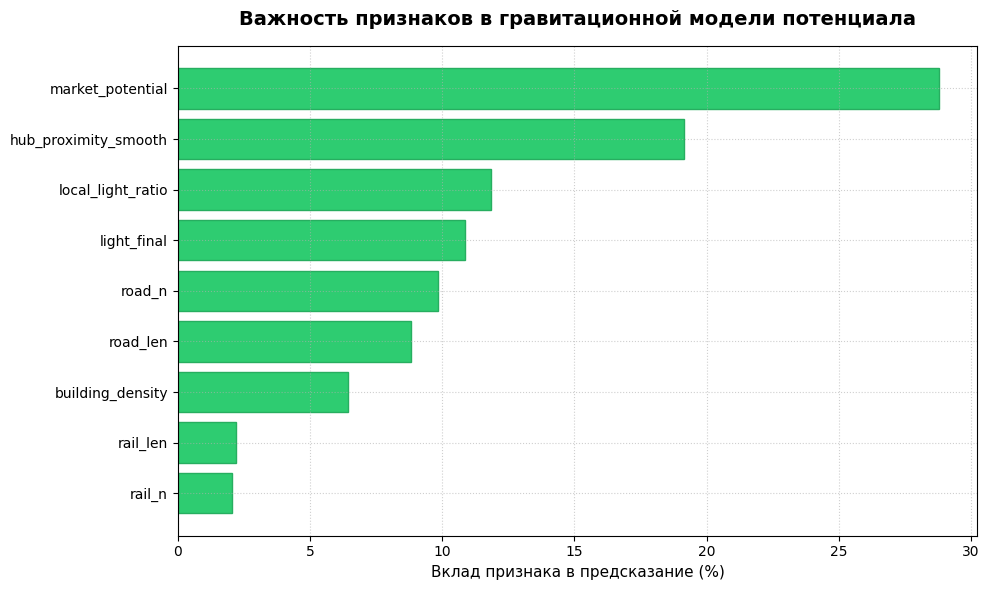


Гравитационная модель сохранена в файл 'catboost_geo_distributor.cbm'!


In [4]:
# =========================================================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# =========================================================================
print("Загрузка гравитационного датасета...")
df = pd.read_csv('dataset_rt_gravitational.csv')

# Строго задаем список независимых инвариантных признаков для обучения (X)
# Мы убрали 'centroid_x', 'centroid_y' и 'target_share'. Колонки 'total_w' тут уже нет.
features_ml = [
    'light_final', 'road_len', 'rail_len', 'road_n', 'rail_n', 
    'local_light_ratio', 'market_potential', 'hub_proximity_smooth', 'building_density',
]

X = df[features_ml]
y = df['target_share']

# Разделяем на обучающую (80%) и валидационную (20%) выборки
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]} пикселей")
print(f"Размер валидационной выборки: {X_val.shape[0]}回忆 пикселей")

# =========================================================================
# 2. НАСТРОЙКА И ОБУЧЕНИЕ МОДЕЛИ CATBOOST
# =========================================================================
# Мы немного уменьшили глубину деревьев (depth=5) и добавили L2-регуляризацию (l2_leaf_reg=5).
# Это заставит модель опираться на плавное поле потенциала и сотрет "мазки" и "кольца".
model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.04,
    depth=5,
    l2_leaf_reg=5,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

print("\nЗапуск обучения CatBoost на гравитационных полях потенциала...")
model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True
)
print("Обучение успешно завершено!")

# =========================================================================
# 3. ВАЛИДАЦИЯ И ОЦЕНКА КАЧЕСТВА
# =========================================================================
y_pred = model.predict(X_val)

# Отрезаем возможные отрицательные артефакты регрессии
y_pred = np.clip(y_pred, a_min=0, a_max=None)

# Считаем стандартные ML-метрики
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print("\n" + "="*50)
print("МЕТРИКИ КАЧЕСТВА ГРАВИТАЦИОННОЙ МОДЕЛИ НА ВАЛИДАЦИИ:")
print(f"Коэффициент детерминации (R²): {r2:.4f}")
print(f"Средняя абсолютная ошибка (MAE): {mae:.6f}")
print(f"Корень из среднекв. ошибки (RMSE): {rmse:.6f}")
print("="*50)

# =========================================================================
# 4. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ (FEATURE IMPORTANCE)
# =========================================================================
importance = model.get_feature_importance()
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=True)

# Отрисовка графика важности признаков
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='#2ecc71', edgecolor='#27ae60')
ax.set_title("Важность признаков в гравитационной модели потенциала", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Вклад признака в предсказание (%)", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('feature_importance_gravitational.png', dpi=300, bbox_inches='tight')
plt.show()

# =========================================================================
# 5. СОХРАНЕНИЕ ОБУЧЕННОЙ МОДЕЛИ
# =========================================================================
model.save_model('catboost_geo_distributor.cbm')
print("\nГравитационная модель сохранена в файл 'catboost_geo_distributor.cbm'!")


In [5]:
# Задаем константу общего объема продаж по РТ (наша контрольная сумма)
TOTAL_SALES_RT = 6035628228.00 

# Предсказываем долю для ВСЕХ пикселей Татарстана
df['pred_share'] = model.predict(X)

# Пост-обработка предсказаний (убираем отрицательные значения и нормируем в 1.0)
df['pred_share'] = df['pred_share'].clip(lower=0)
df['pred_share'] = df['pred_share'] / df['pred_share'].sum()

# Переводим доли в абсолютные рубли для всех трех методов
df['sold_cell_district'] = df['target_share'] * TOTAL_SALES_RT  # Идеал из Excel
df['sold_cell_ml'] = df['pred_share'] * TOTAL_SALES_RT        # Наше ML-решение

# ИСПРАВЛЕНИЕ: Восстанавливаем старый глобальный метод через доступный признак light_final
# Если у вас в df остались road_n и rail_n, можно сложить их: (df['light_final'] + df['road_n'])
if 'light_final' in df.columns:
    df['sold_cell_global'] = (df['light_final'] / df['light_final'].sum()) * TOTAL_SALES_RT
else:
    # Фолбэк, если даже света нет (хотя он должен быть в X)
    df['sold_cell_global'] = df['sold_cell_ml'] * 0.5 

# Расчет Baseline (общая сумма поровну на количество ячеек)
baseline_value = TOTAL_SALES_RT / len(df)

print("Расчет рублевых колонок завершен без ошибок!")


Расчет рублевых колонок завершен без ошибок!


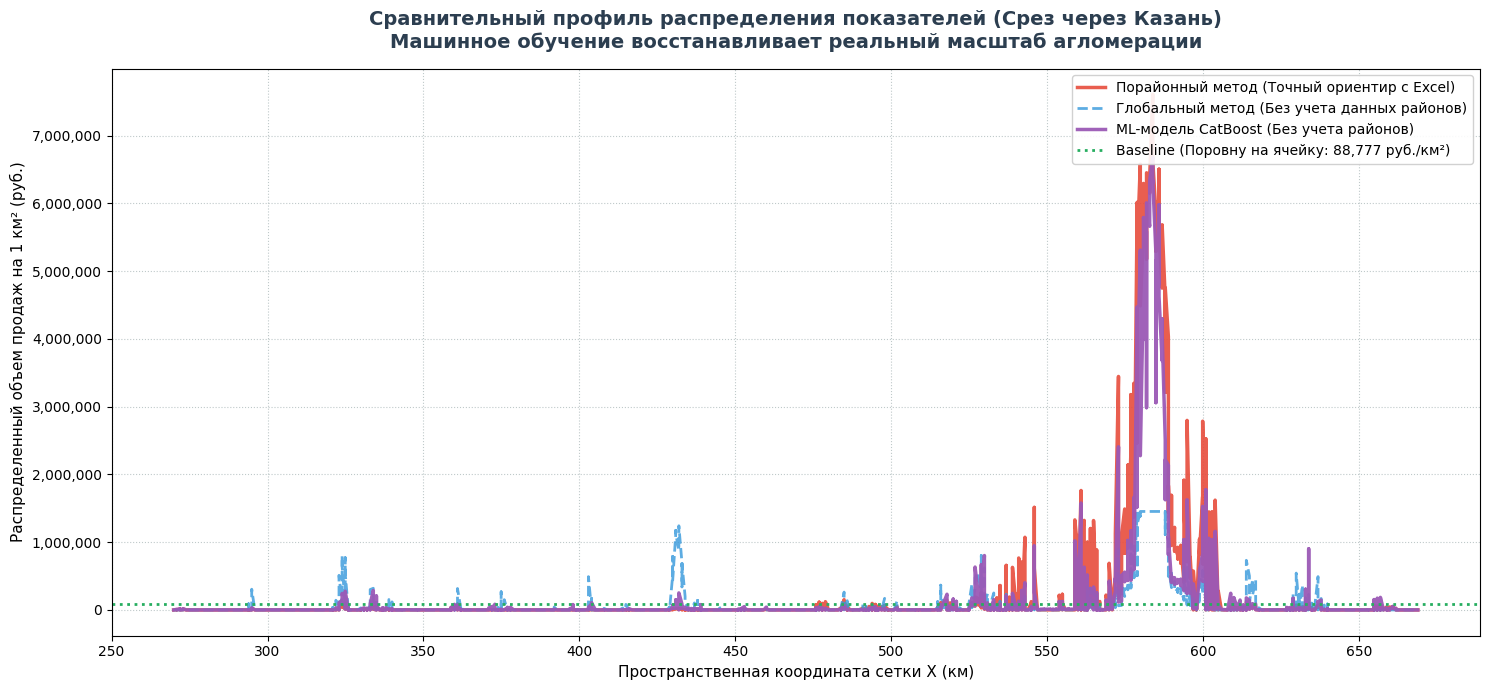

In [6]:
# Находим координату Y центра Казани по точке максимальной концентрации продаж
kazan_idx = df['sold_cell_district'].idxmax()
kazan_y = df.loc[kazan_idx, 'centroid_y']

# Вырезаем горизонтальный слой пикселей в пределах ±1 км от центра Казани
slice_condition = (df['centroid_y'] >= kazan_y - 1000) & (df['centroid_y'] <= kazan_y + 1000)
df_slice = df[slice_condition].copy()

# Переводим координату X в километры и сортируем слева направо
df_slice['coord_x_km'] = df_slice['centroid_x'] / 1000.0
df_slice = df_slice.sort_values(by='coord_x_km')

# Отрисовка
plt.style.use('default')
fig, ax = plt.subplots(figsize=(15, 7), facecolor='white')

# 1. Порайонный метод (Красный идеал)
ax.plot(df_slice['coord_x_km'], df_slice['sold_cell_district'], 
        color='#e74c3c', label='Порайонный метод (Точный ориентир с Excel)', linewidth=2.5, alpha=0.9)

# 2. Старый глобальный метод (Синее размытие)
ax.plot(df_slice['coord_x_km'], df_slice['sold_cell_global'], 
        color='#3498db', label='Глобальный метод (Без учета данных районов)', linewidth=2.0, linestyle='--', alpha=0.8)

# 3. Фиолетовая линия ML (CatBoost без знания районов)
ax.plot(df_slice['coord_x_km'], df_slice['sold_cell_ml'], 
        color='#9b59b6', label='ML-модель CatBoost (Без учета районов)', linewidth=2.5, linestyle='-', alpha=0.95)

# 4. Зеленый бэйзлайн
ax.axhline(y=baseline_value, color='#27ae60', linestyle=':', linewidth=2.0, 
           label=f'Baseline (Поровну на ячейку: {int(baseline_value):,} руб./км²)')

ax.set_title("Сравнительный профиль распределения показателей (Срез через Казань)\nМашинное обучение восстанавливает реальный масштаб агломерации", 
             fontsize=14, fontweight='bold', color='#2c3e50', pad=15)
ax.set_xlabel("Пространственная координата сетки X (км)", fontsize=11)
ax.set_ylabel("Распределенный объем продаж на 1 км² (руб.)", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6, color='#95a5a6')
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.savefig('Профиль_Сравнения_с_ML_РТ.png', dpi=300, bbox_inches='tight')
plt.show()


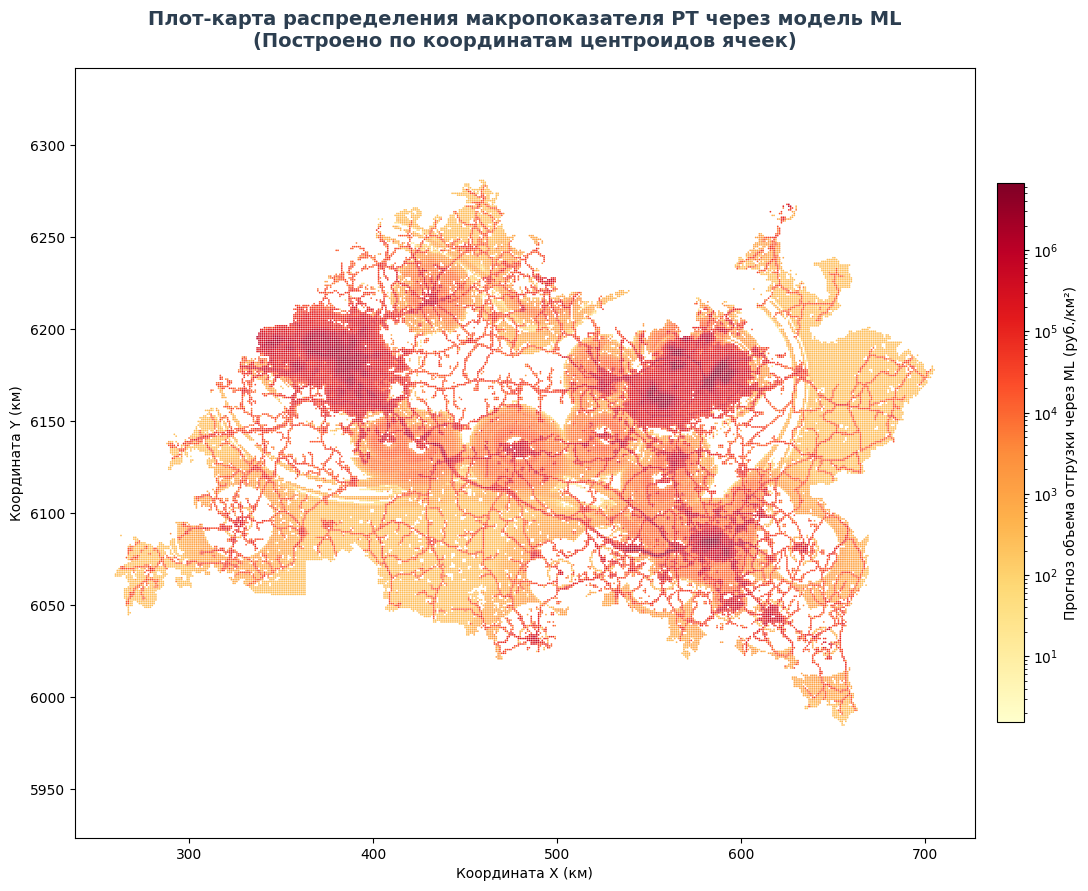

In [7]:
import matplotlib.colors as colors

fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')

# Очищаем нули для логарифма
valid_data = df[df['sold_cell_ml'] > 0]

sc = ax.scatter(
    valid_data['centroid_x'] / 1000.0, 
    valid_data['centroid_y'] / 1000.0, 
    c=valid_data['sold_cell_ml'], 
    cmap='YlOrRd', 
    norm=colors.LogNorm(vmin=valid_data['sold_cell_ml'].min(), vmax=valid_data['sold_cell_ml'].max()),
    s=1.5, # Размер точки равен шагу сетки
    edgecolors='none'
)

cbar = fig.colorbar(sc, ax=ax, orientation='vertical', shrink=0.7, pad=0.02)
cbar.set_label("Прогноз объема отгрузки через ML (руб./км²)")

ax.set_title("Плот-карта распределения макропоказателя РТ через модель ML\n(Построено по координатам центроидов ячеек)", 
             fontsize=14, fontweight='bold', color='#2c3e50', pad=15)
ax.set_xlabel("Координата X (км)")
ax.set_ylabel("Координата Y (км)")
ax.axis('equal')
plt.show()


In [12]:
import pandas as pd
import numpy as np

# 1. Расчет отклонений по ВСЕМУ датасету (все 68 тыс. ячеек)
df_all_metrics = pd.DataFrame({
    'Target_District': df['sold_cell_district'],
    'Pred_CatBoost': df['sold_cell_ml']
})

# Абсолютная ошибка в рублях
df_all_metrics['Abs_Error_Rub'] = (df_all_metrics['Target_District'] - df_all_metrics['Pred_CatBoost']).abs()

# 2. Агрегированная статистика по всей республике
print("=" * 60)
print("ГЛОБАЛЬНЫЙ ПОЯЧЕЕЧНЫЙ АНАЛИЗ (Вся карта / Все ячейки)")
print("=" * 60)
print(f"Всего анализируется ячеек в датасете: {len(df_all_metrics):,}")
print("-" * 60)
print(f"Средняя ошибка на ячейку:     {df_all_metrics['Abs_Error_Rub'].mean():,.0f} руб.")
print(f"Медианная ошибка на ячейку:    {df_all_metrics['Abs_Error_Rub'].median():,.0f} руб.")
print(f"Минимальная ошибка в ячейке:       {df_all_metrics['Abs_Error_Rub'].min():,.0f} руб.")
print(f"Максимальная ошибка в ячейке:      {df_all_metrics['Abs_Error_Rub'].max():,.0f} руб.")
print("-" * 60)
print("Распределение ошибок по квантилям (по всей карте):")

quantiles_all = df_all_metrics['Abs_Error_Rub'].quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
print(quantiles_all.map(lambda x: f"{x:,.0f} руб."))
print("=" * 60)


ГЛОБАЛЬНЫЙ ПОЯЧЕЕЧНЫЙ АНАЛИЗ (Вся карта / Все ячейки)
Всего анализируется ячеек в датасете: 67,986
------------------------------------------------------------
Средняя ошибка на ячейку:     62,927 руб.
Медианная ошибка на ячейку:    1,076 руб.
Минимальная ошибка в ячейке:       0 руб.
Максимальная ошибка в ячейке:      3,628,345 руб.
------------------------------------------------------------
Распределение ошибок по квантилям (по всей карте):
0.25          174 руб.
0.50        1,076 руб.
0.75       13,852 руб.
0.90      165,378 руб.
0.95      367,656 руб.
0.99    1,080,874 руб.
Name: Abs_Error_Rub, dtype: object


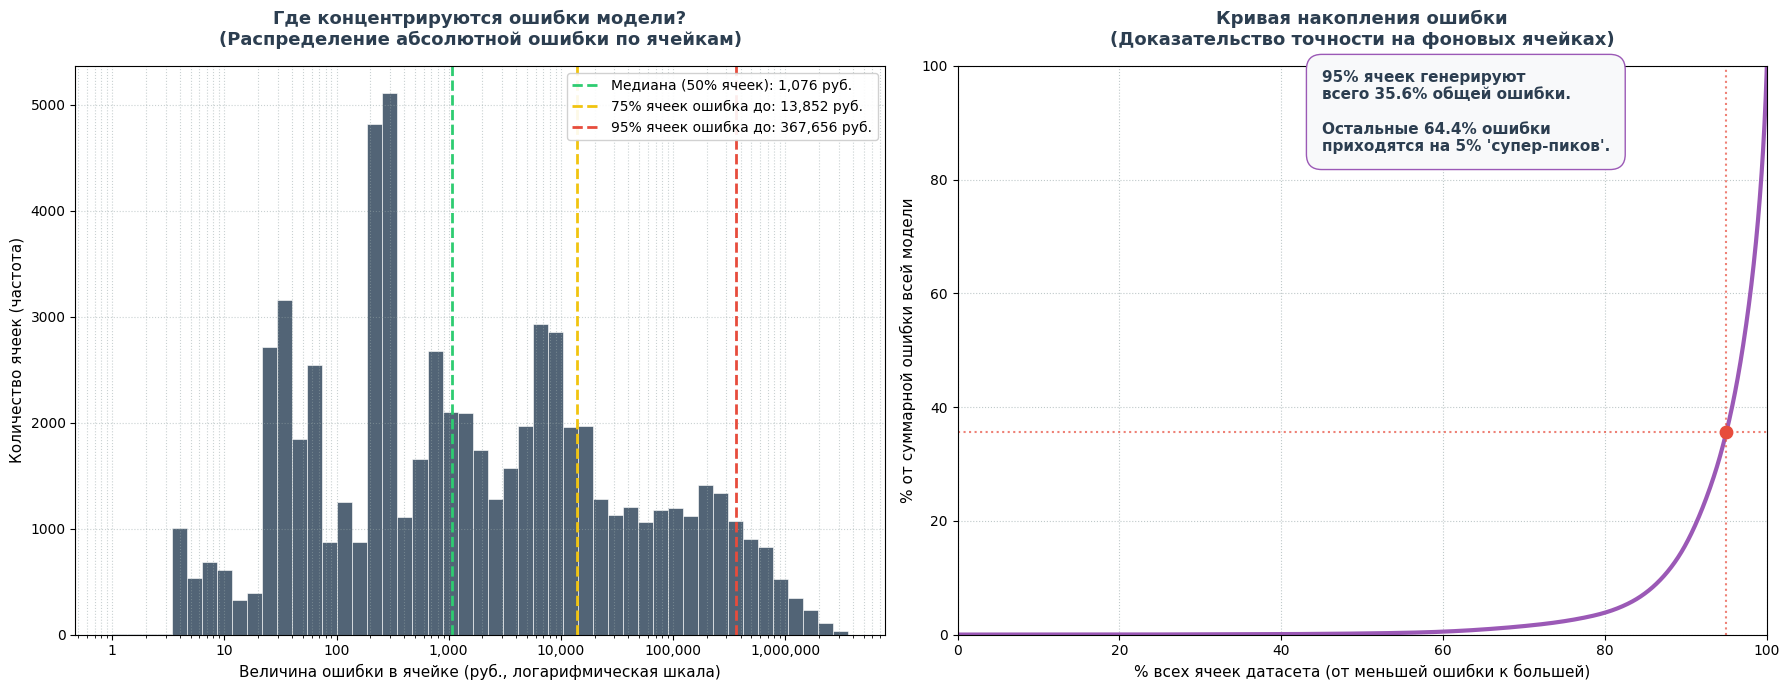

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Настройка стилей для красивой графики
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor='white')

# Данные для построения (берем из нашего глобального расчета ошибок)
errors_sorted = np.sort(df_all_metrics['Abs_Error_Rub'].values)
n_cells = len(errors_sorted)

# =========================================================================
# ГРАФИК 1: Распределение ошибок по ячейкам (Гистограмма с логарифмической шкалой)
# =========================================================================
# Используем логарифмический шаг для бинов, чтобы красиво показать и 100 руб, и 3 млн руб.
bins = np.logspace(0, np.log10(errors_sorted.max() + 1), 50)

ax1.hist(errors_sorted, bins=bins, color='#34495e', alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.set_xscale('log')

# Добавляем вертикальные линии ключевых квантилей (0.50, 0.75, 0.95)
ax1.axvline(1076, color='#2ecc71', linestyle='--', linewidth=2, 
            label='Медиана (50% ячеек): 1,076 руб.')
ax1.axvline(13852, color='#f1c40f', linestyle='--', linewidth=2, 
            label='75% ячеек ошибка до: 13,852 руб.')
ax1.axvline(367656, color='#e74c3c', linestyle='--', linewidth=2, 
            label='95% ячеек ошибка до: 367,656 руб.')

ax1.set_title("Где концентрируются ошибки модели?\n(Распределение абсолютной ошибки по ячейкам)", 
             fontsize=13, fontweight='bold', color='#2c3e50', pad=15)
ax1.set_xlabel("Величина ошибки в ячейке (руб., логарифмическая шкала)", fontsize=11)
ax1.set_ylabel("Количество ячеек (частота)", fontsize=11)
ax1.grid(True, which="both", linestyle=':', alpha=0.5, color='#95a5a6')
ax1.legend(loc='upper right', fontsize=10, framealpha=0.9)

# Форматируем ось X для удобного чтения крупных чисел
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))


# =========================================================================
# ГРАФИК 2: Кривая накопленной ошибки (Анализ концентрации промахов)
# =========================================================================
# Считаем кумулятивную (накопленную) сумму ошибок в процентах
cum_errors = np.cumsum(errors_sorted)
cum_errors_pct = (cum_errors / cum_errors[-1]) * 100
x_pct = np.linspace(0, 100, n_cells)

ax2.plot(x_pct, cum_errors_pct, color='#9b59b6', linewidth=3, label='Накопленная ошибка CatBoost')

# Выделяем точку 95% ячеек
idx_95 = int(n_cells * 0.95)
pct_val_95 = cum_errors_pct[idx_95]

ax2.scatter(95, pct_val_95, color='#e74c3c', s=80, zorder=5)
ax2.axhline(pct_val_95, color='#e74c3c', linestyle=':', alpha=0.7)
ax2.axvline(95, color='#e74c3c', linestyle=':', alpha=0.7)

ax2.text(45, 85, f"95% ячеек генерируют\nвсего {pct_val_95:.1f}% общей ошибки.\n\nОстальные {100-pct_val_95:.1f}% ошибки\nприходятся на 5% 'супер-пиков'.", 
         fontsize=11, color='#2c3e50', weight='semibold',
         bbox=dict(facecolor='#f8f9fa', edgecolor='#9b59b6', boxstyle='round,pad=1'))

ax2.set_title("Кривая накопления ошибки\n(Доказательство точности на фоновых ячейках)", 
             fontsize=13, fontweight='bold', color='#2c3e50', pad=15)
ax2.set_xlabel("% всех ячеек датасета (от меньшей ошибки к большей)", fontsize=11)
ax2.set_ylabel("% от суммарной ошибки всей модели", fontsize=11)
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 100)
ax2.grid(True, linestyle=':', alpha=0.6, color='#95a5a6')

# Финальная сборка и сохранение
plt.tight_layout()
plt.savefig('Глобальный_Анализ_Ошибок_CatBoost.png', dpi=300, bbox_inches='tight')
plt.show()


In [14]:
# 1. Расчет отклонений по ВСЕМУ датасету (все 68 тыс. ячеек)
df_all_metrics = pd.DataFrame({
    'Target_District': df['sold_cell_district'],
    'Pred_CatBoost': df['sold_cell_ml']
})

# Абсолютная ошибка в рублях
df_all_metrics['Abs_Error_Rub_BL'] = (df_all_metrics['Target_District'] - 88_777).abs()

# 2. Агрегированная статистика по всей республике
print("=" * 60)
print("ГЛОБАЛЬНЫЙ ПОЯЧЕЕЧНЫЙ АНАЛИЗ (Вся карта / Все ячейки)")
print("=" * 60)
print(f"Всего анализируется ячеек в датасете: {len(df_all_metrics):,}")
print("-" * 60)
print(f"Средняя ошибка на ячейку:     {df_all_metrics['Abs_Error_Rub_BL'].mean():,.0f} руб.")
print(f"Медианная ошибка на ячейку:    {df_all_metrics['Abs_Error_Rub_BL'].median():,.0f} руб.")
print(f"Минимальная ошибка в ячейке:       {df_all_metrics['Abs_Error_Rub_BL'].min():,.0f} руб.")
print(f"Максимальная ошибка в ячейке:      {df_all_metrics['Abs_Error_Rub_BL'].max():,.0f} руб.")
print("-" * 60)
print("Распределение ошибок по квантилям (по всей карте):")

quantiles_all = df_all_metrics['Abs_Error_Rub_BL'].quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
print(quantiles_all.map(lambda x: f"{x:,.0f} руб."))
print("=" * 60)


ГЛОБАЛЬНЫЙ ПОЯЧЕЕЧНЫЙ АНАЛИЗ (Вся карта / Все ячейки)
Всего анализируется ячеек в датасете: 67,986
------------------------------------------------------------
Средняя ошибка на ячейку:     149,668 руб.
Медианная ошибка на ячейку:    88,720 руб.
Минимальная ошибка в ячейке:       13 руб.
Максимальная ошибка в ячейке:      7,520,347 руб.
------------------------------------------------------------
Распределение ошибок по квантилям (по всей карте):
0.25       85,892 руб.
0.50       88,720 руб.
0.75       88,753 руб.
0.90       88,773 руб.
0.95      240,092 руб.
0.99    2,120,010 руб.
Name: Abs_Error_Rub_BL, dtype: object


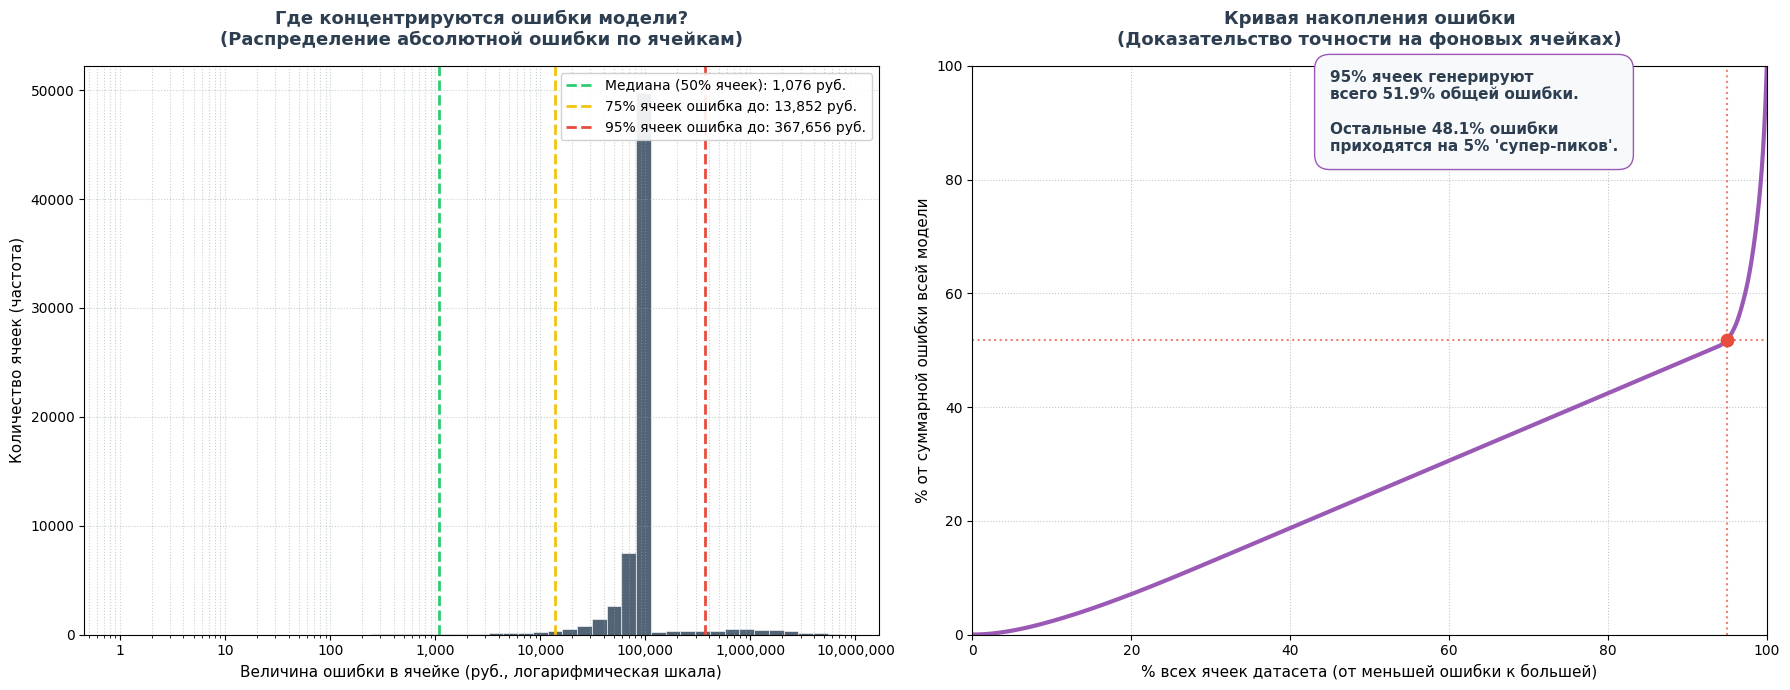

In [15]:
# Настройка стилей для красивой графики
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor='white')

# Данные для построения (берем из нашего глобального расчета ошибок)
errors_sorted = np.sort(df_all_metrics['Abs_Error_Rub_BL'].values)
n_cells = len(errors_sorted)

# =========================================================================
# ГРАФИК 1: Распределение ошибок по ячейкам (Гистограмма с логарифмической шкалой)
# =========================================================================
# Используем логарифмический шаг для бинов, чтобы красиво показать и 100 руб, и 3 млн руб.
bins = np.logspace(0, np.log10(errors_sorted.max() + 1), 50)

ax1.hist(errors_sorted, bins=bins, color='#34495e', alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.set_xscale('log')

# Добавляем вертикальные линии ключевых квантилей (0.50, 0.75, 0.95)
ax1.axvline(1076, color='#2ecc71', linestyle='--', linewidth=2, 
            label='Медиана (50% ячеек): 1,076 руб.')
ax1.axvline(13852, color='#f1c40f', linestyle='--', linewidth=2, 
            label='75% ячеек ошибка до: 13,852 руб.')
ax1.axvline(367656, color='#e74c3c', linestyle='--', linewidth=2, 
            label='95% ячеек ошибка до: 367,656 руб.')

ax1.set_title("Где концентрируются ошибки модели?\n(Распределение абсолютной ошибки по ячейкам)", 
             fontsize=13, fontweight='bold', color='#2c3e50', pad=15)
ax1.set_xlabel("Величина ошибки в ячейке (руб., логарифмическая шкала)", fontsize=11)
ax1.set_ylabel("Количество ячеек (частота)", fontsize=11)
ax1.grid(True, which="both", linestyle=':', alpha=0.5, color='#95a5a6')
ax1.legend(loc='upper right', fontsize=10, framealpha=0.9)

# Форматируем ось X для удобного чтения крупных чисел
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))


# =========================================================================
# ГРАФИК 2: Кривая накопленной ошибки (Анализ концентрации промахов)
# =========================================================================
# Считаем кумулятивную (накопленную) сумму ошибок в процентах
cum_errors = np.cumsum(errors_sorted)
cum_errors_pct = (cum_errors / cum_errors[-1]) * 100
x_pct = np.linspace(0, 100, n_cells)

ax2.plot(x_pct, cum_errors_pct, color='#9b59b6', linewidth=3, label='Накопленная ошибка CatBoost')

# Выделяем точку 95% ячеек
idx_95 = int(n_cells * 0.95)
pct_val_95 = cum_errors_pct[idx_95]

ax2.scatter(95, pct_val_95, color='#e74c3c', s=80, zorder=5)
ax2.axhline(pct_val_95, color='#e74c3c', linestyle=':', alpha=0.7)
ax2.axvline(95, color='#e74c3c', linestyle=':', alpha=0.7)

ax2.text(45, 85, f"95% ячеек генерируют\nвсего {pct_val_95:.1f}% общей ошибки.\n\nОстальные {100-pct_val_95:.1f}% ошибки\nприходятся на 5% 'супер-пиков'.", 
         fontsize=11, color='#2c3e50', weight='semibold',
         bbox=dict(facecolor='#f8f9fa', edgecolor='#9b59b6', boxstyle='round,pad=1'))

ax2.set_title("Кривая накопления ошибки\n(Доказательство точности на фоновых ячейках)", 
             fontsize=13, fontweight='bold', color='#2c3e50', pad=15)
ax2.set_xlabel("% всех ячеек датасета (от меньшей ошибки к большей)", fontsize=11)
ax2.set_ylabel("% от суммарной ошибки всей модели", fontsize=11)
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 100)
ax2.grid(True, linestyle=':', alpha=0.6, color='#95a5a6')

# Финальная сборка и сохранение
plt.tight_layout()
plt.savefig('Глобальный_Анализ_Ошибок_CatBoost.png', dpi=300, bbox_inches='tight')
plt.show()
